In [1]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset downloaded to:
/kaggle/input/covid19-radiography-database


In [2]:
import os

print("Files and folders:")
for item in os.listdir(path):
    print(item)

Files and folders:
COVID-19_Radiography_Dataset


In [3]:
dataset_path = os.path.join(path, "COVID-19_Radiography_Dataset")

print(os.listdir(dataset_path))
print(dataset_path)

['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']
/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [4]:
# Image directories only
image_dirs = {
    "COVID": os.path.join(dataset_path, "COVID"),
    "Lung_Opacity": os.path.join(dataset_path, "Lung_Opacity"),
    "Normal": os.path.join(dataset_path, "Normal"),
    "Viral_Pneumonia": os.path.join(dataset_path, "Viral Pneumonia")
}

# Display directories
for label, directory in image_dirs.items():
    print(label, ":", directory)

COVID : /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID
Lung_Opacity : /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity
Normal : /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal
Viral_Pneumonia : /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia


In [5]:
for label, directory in image_dirs.items():
    images = os.listdir(directory)
    print(f"{label}: {len(images)} images")
    print("First 5:", images[:5])
    print()

COVID: 2 images
First 5: ['images', 'masks']

Lung_Opacity: 2 images
First 5: ['images', 'masks']

Normal: 2 images
First 5: ['images', 'masks']

Viral_Pneumonia: 2 images
First 5: ['images', 'masks']



In [7]:
import os
import glob
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import EfficientNetB0

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Image size ----
# 224x224 matches DenseNet121's native ImageNet input resolution and keeps
# Colab training times/memory reasonable. A larger size (e.g. 512x512) would
# not meaningfully help a pretrained backbone here and would roughly 5x the
# compute/memory cost for both models.
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
MASK_SIZE = 224

BATCH_SIZE = 32

# Fixed, alphabetically-sorted class order used everywhere in this notebook
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
NUM_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}
index_to_label = {i: name for name, i in label_to_index.items()}

# Update this to wherever the dataset lives in your Colab session
# (e.g. after mounting Drive or unzipping the Kaggle download).
DATASET_ROOT = dataset_path

# Independent output artifacts -- these do NOT touch or overwrite any
# existing multi-task model files you already have.
CLASSIFICATION_MODEL_PATH = "chest_xray_classifier.keras"
SEGMENTATION_MODEL_PATH = "lung_segmentation.keras"
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Classification: staged transfer-learning config
STAGE1_EPOCHS = 15          # frozen backbone, train head only
STAGE2_EPOCHS = 20          # fine-tune unfrozen tail of backbone
STAGE1_LR = 1e-3
STAGE2_LR = 1e-5
FINE_TUNE_AT_LAYER_FRACTION = 0.7   # unfreeze last 30% of DenseNet121 layers in stage 2

# Segmentation config
SEG_EPOCHS = 40
SEG_LR = 1e-4

In [9]:
def build_file_index(dataset_root, class_names):
    """
    Scans dataset_root/<class>/images and dataset_root/<class>/masks and
    returns a DataFrame with columns: image_path, mask_path, label.

    Assumes mask filenames match image filenames (the standard layout for
    the COVID-19 Radiography Database). Falls back to matching by filename
    stem if the extension differs.
    """
    records = []
    for cls in class_names:
        img_dir = os.path.join(dataset_root, cls, "images")
        mask_dir = os.path.join(dataset_root, cls, "masks")
        if not os.path.isdir(img_dir):
            print(f"WARNING: missing image dir for class '{cls}': {img_dir}")
            continue

        img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))
        for img_path in img_paths:
            fname = os.path.basename(img_path)
            mask_path = os.path.join(mask_dir, fname)
            if not os.path.exists(mask_path):
                stem = os.path.splitext(fname)[0]
                candidates = glob.glob(os.path.join(mask_dir, stem + ".*"))
                mask_path = candidates[0] if candidates else None
            records.append({"image_path": img_path, "mask_path": mask_path, "label": cls})

    return pd.DataFrame(records)

file_index = build_file_index(DATASET_ROOT, CLASS_NAMES)
print("Total images found:", len(file_index))
print("Images missing a mask:", file_index["mask_path"].isna().sum())
file_index.head()

Total images found: 21165
Images missing a mask: 0


,image_path,mask_path,label
0,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,COVID
1,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,COVID
2,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,COVID
3,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,COVID
4,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,COVID


In [10]:
assert len(file_index) > 0, "No images found -- check DATASET_ROOT and folder structure."

# Spot-check a few images/masks actually open and have sane shapes
sample_rows = file_index.sample(min(5, len(file_index)), random_state=SEED)
for _, row in sample_rows.iterrows():
    img = cv2.imread(row["image_path"])
    assert img is not None, f"Failed to read image: {row['image_path']}"
    if isinstance(row["mask_path"], str):
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        assert mask is not None, f"Failed to read mask: {row['mask_path']}"
    print(row["label"], "-> image shape:", img.shape)

print("\nDataset verification passed.")

Viral Pneumonia -> image shape: (299, 299, 3)
Normal -> image shape: (299, 299, 3)
COVID -> image shape: (299, 299, 3)
Normal -> image shape: (299, 299, 3)
Normal -> image shape: (299, 299, 3)

Dataset verification passed.


label
COVID               3616
Lung_Opacity        6012
Normal             10192
Viral Pneumonia     1345
Name: count, dtype: int64


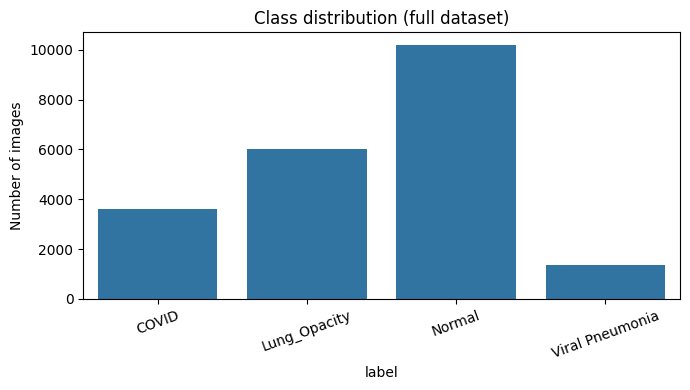

In [11]:
class_counts = file_index["label"].value_counts().reindex(CLASS_NAMES)
print(class_counts)

plt.figure(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution (full dataset)")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
train_df, temp_df = train_test_split(
    file_index, test_size=0.30, stratify=file_index["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
print("\nTrain distribution:\n", train_df["label"].value_counts())
print("\nVal distribution:\n", val_df["label"].value_counts())
print("\nTest distribution:\n", test_df["label"].value_counts())

train_df.to_csv(os.path.join(ARTIFACTS_DIR, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(ARTIFACTS_DIR, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(ARTIFACTS_DIR, "test_split.csv"), index=False)

Train: 14815  Val: 3175  Test: 3175

Train distribution:
 label
Normal             7134
Lung_Opacity       4208
COVID              2531
Viral Pneumonia     942
Name: count, dtype: int64

Val distribution:
 label
Normal             1529
Lung_Opacity        902
COVID               543
Viral Pneumonia     201
Name: count, dtype: int64

Test distribution:
 label
Normal             1529
Lung_Opacity        902
COVID               542
Viral Pneumonia     202
Name: count, dtype: int64


In [13]:
def load_and_preprocess_image(path, training=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if training:
        img = tf.image.random_flip_left_right(img)          # anatomically plausible (L/R mirror)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
        # Small random crop instead of large rotation: X-rays have a fixed
        # anatomical orientation, so aggressive rotation/up-down flips would
        # create implausible training examples.
        img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 20, IMG_SIZE + 20)
        img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])

    img = densenet_preprocess(img)   # DenseNet121-specific preprocessing
    return img

def make_classification_dataset(df, training=False, batch_size=BATCH_SIZE):
    paths = df["image_path"].values
    labels = df["label"].map(label_to_index).values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    def _map_fn(path, label):
        img = load_and_preprocess_image(path, training=training)
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_classification_dataset(train_df, training=True)
val_ds = make_classification_dataset(val_df, training=False)
test_ds = make_classification_dataset(test_df, training=False)

In [14]:
train_labels_idx = train_df["label"].map(label_to_index).values
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels_idx
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:", {index_to_label[i]: round(w, 3) for i, w in class_weight_dict.items()})

Class weights: {'COVID': np.float64(1.463), 'Lung_Opacity': np.float64(0.88), 'Normal': np.float64(0.519), 'Viral Pneumonia': np.float64(3.932)}


In [ ]:
def build_classifier(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    base_model = DenseNet121(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False  # Stage 1: fully frozen backbone

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="chest_xray_densenet121_classifier")
    return model, base_model

classifier, densenet_base = build_classifier()
classifier.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "chest_xray_densenet121_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
classifier.compile(
    optimizer=optimizers.Adam(learning_rate=STAGE1_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

In [ ]:
stage1_callbacks = [
    callbacks.ModelCheckpoint(os.path.join(ARTIFACTS_DIR, "classifier_stage1_best.keras"),
                               monitor="val_loss", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

In [ ]:
history_stage1 = classifier.fit(
    train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS,
    class_weight=class_weight_dict, callbacks=stage1_callbacks,
)

Epoch 1/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 185s 334ms/step - accuracy: 0.7515 - auc: 0.9307 - loss: 0.5897 - val_accuracy: 0.8523 - val_auc: 0.9727 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - accuracy: 0.8125 - auc: 0.9575 - loss: 0.4401 - val_accuracy: 0.8680 - val_auc: 0.9761 - val_loss: 0.3936 - learning_rate: 0.0010
Epoch 3/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 141ms/step - accuracy: 0.8248 - auc: 0.9628 - loss: 0.4113 - val_accuracy: 0.8696 - val_auc: 0.9771 - val_loss: 0.3910 - learning_rate: 0.0010
Epoch 4/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.8403 - auc: 0.9674 - loss: 0.3831 - val_accuracy: 0.8702 - val_auc: 0.9769 - val_loss: 0.3932 - learning_rate: 0.0010
Epoch 5/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 76s 164ms/step - accuracy: 0.8442 - auc: 0.9705 - loss: 0.3700 - val_accuracy: 0.8907 - val_auc: 0.9817 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 6/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - accurac

In [ ]:
densenet_base.trainable = True
fine_tune_at = int(len(densenet_base.layers) * FINE_TUNE_AT_LAYER_FRACTION)
for layer in densenet_base.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNorm layers frozen even within the unfrozen tail: updating BN
# running statistics on a comparatively small medical-imaging dataset tends
# to destabilize the pretrained ImageNet statistics and hurts fine-tuning.
for layer in densenet_base.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Unfrozen layers: {len(densenet_base.layers) - fine_tune_at} / {len(densenet_base.layers)}")

Unfrozen layers: 129 / 427


In [ ]:
classifier.compile(
    optimizer=optimizers.Adam(learning_rate=STAGE2_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

In [ ]:
stage2_callbacks = [
    callbacks.ModelCheckpoint(os.path.join(ARTIFACTS_DIR, "classifier_stage2_best.keras"),
                               monitor="val_loss", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
]

In [ ]:
history_stage2 = classifier.fit(
    train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS,
    class_weight=class_weight_dict, callbacks=stage2_callbacks,
)

Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.8863 - auc: 0.9823 - loss: 0.2981 - val_accuracy: 0.9087 - val_auc: 0.9868 - val_loss: 0.3075 - learning_rate: 1.0000e-05
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 78s 169ms/step - accuracy: 0.8946 - auc: 0.9851 - loss: 0.2701 - val_accuracy: 0.9181 - val_auc: 0.9892 - val_loss: 0.2846 - learning_rate: 1.0000e-05
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - accuracy: 0.9050 - auc: 0.9872 - loss: 0.2523 - val_accuracy: 0.9169 - val_auc: 0.9891 - val_loss: 0.2844 - learning_rate: 1.0000e-05
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.9061 - auc: 0.9867 - loss: 0.2546 - val_accuracy: 0.9162 - val_auc: 0.9896 - val_loss: 0.2810 - learning_rate: 1.0000e-05
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 92s 165ms/step - accuracy: 0.9095 - auc: 0.9881 - loss: 0.2401 - val_accuracy: 0.9203 - val_auc: 0.9905 - val_loss: 0.2690 - learning_rate: 1.0000e-05
Epoch 6/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 

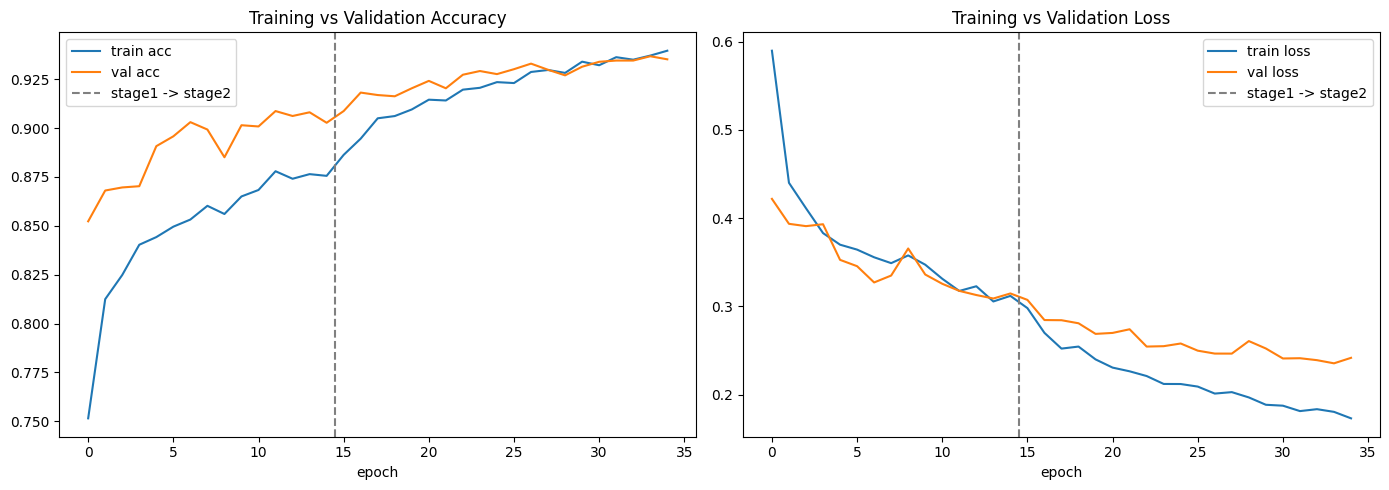

In [ ]:
def combine_histories(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history.get(k, [])
    return combined

full_history = combine_histories(history_stage1, history_stage2)
with open(os.path.join(ARTIFACTS_DIR, "classification_history.json"), "w") as f:
    json.dump(full_history, f)

stage1_len = len(history_stage1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(full_history["accuracy"], label="train acc")
axes[0].plot(full_history["val_accuracy"], label="val acc")
axes[0].axvline(x=stage1_len - 0.5, color="gray", linestyle="--", label="stage1 -> stage2")
axes[0].set_title("Training vs Validation Accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(full_history["loss"], label="train loss")
axes[1].plot(full_history["val_loss"], label="val loss")
axes[1].axvline(x=stage1_len - 0.5, color="gray", linestyle="--", label="stage1 -> stage2")
axes[1].set_title("Training vs Validation Loss"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "classification_training_curves.png"), dpi=150)
plt.show()

In [ ]:
def get_true_and_pred(model, dataset):
    y_true, y_pred_probs = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_pred_probs.append(probs)
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred_probs)

y_true_oh, y_pred_probs = get_true_and_pred(classifier, test_ds)
y_true = np.argmax(y_true_oh, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")

print(f"Accuracy:        {acc:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:      {weighted_f1:.4f}")
print(f"Macro Precision:  {precision_macro:.4f}")
print(f"Macro Recall:     {recall_macro:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Accuracy:        0.9354
Macro F1:        0.9406
Weighted F1:      0.9353
Macro Precision:  0.9473
Macro Recall:     0.9344

Classification Report:

                 precision    recall  f1-score   support

          COVID     0.9645    0.9520    0.9582       542
   Lung_Opacity     0.9325    0.8880    0.9097       902
         Normal     0.9230    0.9568    0.9396      1529
Viral Pneumonia     0.9694    0.9406    0.9548       202

       accuracy                         0.9354      3175
      macro avg     0.9473    0.9344    0.9406      3175
   weighted avg     0.9357    0.9354    0.9353      3175



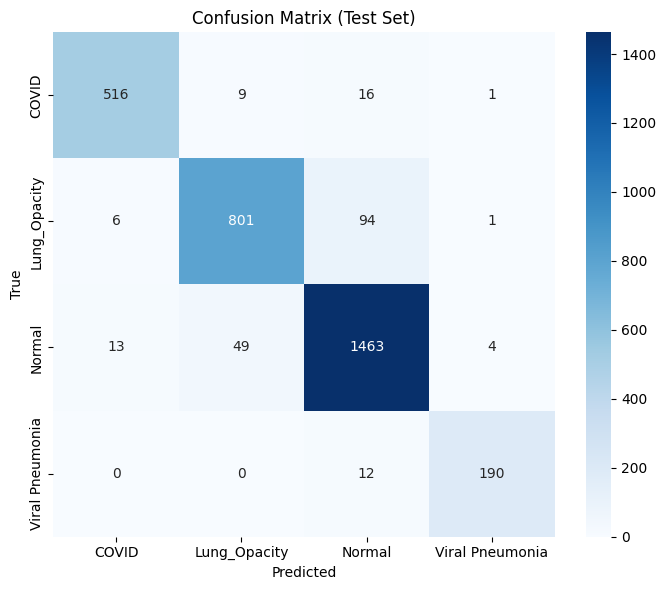

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# One-vs-rest ROC-AUC per class, since this is a multiclass problem
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
roc_auc_per_class = {cls: roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i]) for i, cls in enumerate(CLASS_NAMES)}
macro_roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average="macro", multi_class="ovr")

print("Per-class ROC-AUC:")
for cls, val in roc_auc_per_class.items():
    print(f"  {cls}: {val:.4f}")
print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")

evaluation_results = {
    "accuracy": float(acc), "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
    "macro_precision": float(precision_macro), "macro_recall": float(recall_macro),
    "roc_auc_per_class": {k: float(v) for k, v in roc_auc_per_class.items()},
    "macro_roc_auc": float(macro_roc_auc),
    "classification_report": classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True),
}
with open(os.path.join(ARTIFACTS_DIR, "classification_evaluation.json"), "w") as f:
    json.dump(evaluation_results, f, indent=2)

Per-class ROC-AUC:
  COVID: 0.9979
  Lung_Opacity: 0.9855
  Normal: 0.9837
  Viral Pneumonia: 0.9995
Macro ROC-AUC: 0.9917


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

source = "/content/artifacts"
destination = "/content/drive/MyDrive/artifacts"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Folder saved to Google Drive!")

Folder saved to Google Drive!


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/artifacts/classifier_stage2_best.keras"

classifier = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")
classifier.summary()

Model loaded successfully!


Model: "chest_xray_densenet121_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,545,806 (51.67 MB)

 Trainable params: 3,120,388 (11.90 MB)

 Non-trainable params: 4,184,640 (15.96 MB)

 Optimizer params: 6,240,778 (23.81 MB)

In [ ]:
print("========== CLASSIFIER ==========")

for i, layer in enumerate(classifier.layers):
    print(
        i,
        "|",
        layer.name,
        "|",
        type(layer).__name__,
        "|",
        getattr(layer, "output_shape", "N/A")
    )


print("\n========== NESTED MODELS ==========")

for layer in classifier.layers:
    if isinstance(layer, keras.Model):

        print("\nModel:", layer.name)

        for i, sublayer in enumerate(layer.layers[-10:]):
            print(
                i,
                sublayer.name,
                type(sublayer).__name__
            )

========== CLASSIFIER ==========
0 | input_layer_1 | InputLayer | N/A
1 | densenet121 | Functional | (None, 7, 7, 1024)
2 | gap | GlobalAveragePooling2D | N/A
3 | batch_normalization | BatchNormalization | N/A
4 | dropout | Dropout | N/A
5 | dense | Dense | N/A
6 | dropout_1 | Dropout | N/A
7 | predictions | Dense | N/A

========== NESTED MODELS ==========

Model: densenet121
0 conv5_block15_concat Concatenate
1 conv5_block16_0_bn BatchNormalization
2 conv5_block16_0_relu Activation
3 conv5_block16_1_conv Conv2D
4 conv5_block16_1_bn BatchNormalization
5 conv5_block16_1_relu Activation
6 conv5_block16_2_conv Conv2D
7 conv5_block16_concat Concatenate
8 bn BatchNormalization
9 relu Activation


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


# ============================================================
# 1. Get the actual DenseNet backbone
# ============================================================

densenet_base = classifier.get_layer("densenet121")

print("DenseNet:", densenet_base.name)
print("DenseNet output:", densenet_base.output_shape)


# ============================================================
# 2. Grad-CAM
# ============================================================

def make_gradcam_heatmap(img_array, classifier, densenet_base, pred_index=None):

    with tf.GradientTape() as tape:

        # --------------------------------------------
        # Forward pass through DenseNet
        # --------------------------------------------
        conv_outputs = densenet_base(
            img_array,
            training=False
        )

        # Tell GradientTape to watch this feature map
        tape.watch(conv_outputs)

        # --------------------------------------------
        # Forward pass through classifier head
        # --------------------------------------------
        x = conv_outputs

        # gap
        x = classifier.get_layer("gap")(
            x,
            training=False
        )

        # batch normalization
        x = classifier.get_layer("batch_normalization")(
            x,
            training=False
        )

        # dropout
        x = classifier.get_layer("dropout")(
            x,
            training=False
        )

        # dense
        x = classifier.get_layer("dense")(
            x,
            training=False
        )

        # dropout_1
        x = classifier.get_layer("dropout_1")(
            x,
            training=False
        )

        # final predictions
        predictions = classifier.get_layer("predictions")(
            x,
            training=False
        )

        # --------------------------------------------
        # Select predicted class
        # --------------------------------------------
        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[:, pred_index]

    # ========================================================
    # Calculate gradients
    # ========================================================

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:
        raise ValueError(
            "Gradients are None. "
            "The classifier head is not connected to DenseNet output."
        )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(
        heatmap
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return (
        heatmap.numpy(),
        int(pred_index),
        predictions.numpy()[0]
    )

DenseNet: densenet121
DenseNet output: (None, 7, 7, 1024)


In [ ]:
def load_raw_image_for_display(path, size=IMG_SIZE):

    img = tf.io.read_file(path)

    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.resize(
        img,
        [size, size]
    )

    return tf.cast(
        img,
        tf.uint8
    ).numpy()

In [ ]:
def load_raw_image_for_display(path, size=IMG_SIZE):

    img = tf.io.read_file(path)

    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.resize(
        img,
        [size, size]
    )

    return tf.cast(
        img,
        tf.uint8
    ).numpy()

In [ ]:
def overlay_gradcam(
    original_img_uint8,
    heatmap,
    alpha=0.4
):

    heatmap_resized = cv2.resize(
        heatmap,
        (
            original_img_uint8.shape[1],
            original_img_uint8.shape[0]
        )
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_img_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay, heatmap_color

In [ ]:
def generate_gradcam_for_image(
    image_path,
    classifier=classifier,
    densenet_base=densenet_base,
    class_names=CLASS_NAMES
):

    # --------------------------------------------
    # Load image
    # --------------------------------------------

    raw_img = load_raw_image_for_display(
        image_path
    )

    # --------------------------------------------
    # DenseNet preprocessing
    # --------------------------------------------

    preprocessed = densenet_preprocess(
        tf.cast(raw_img, tf.float32)
    )

    img_array = tf.expand_dims(
        preprocessed,
        axis=0
    )

    # --------------------------------------------
    # Generate Grad-CAM
    # --------------------------------------------

    heatmap, pred_index, probs = make_gradcam_heatmap(
        img_array,
        classifier,
        densenet_base
    )

    # --------------------------------------------
    # Overlay
    # --------------------------------------------

    overlay, heatmap_color = overlay_gradcam(
        raw_img,
        heatmap
    )

    return {
        "raw_image": raw_img,
        "heatmap": heatmap,
        "heatmap_color": heatmap_color,
        "overlay": overlay,

        "predicted_class": class_names[pred_index],
        "predicted_index": pred_index,

        "confidence": float(
            probs[pred_index]
        ),

        "probabilities": {
            class_names[i]: float(probs[i])
            for i in range(len(class_names))
        }
    }

In [ ]:
def display_gradcam_result(result):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        result["raw_image"]
    )
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(
        result["heatmap"],
        cmap="jet"
    )
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(
        result["overlay"]
    )
    axes[2].set_title("Grad-CAM Overlay")
    axes[2].axis("off")

    fig.suptitle(
        f"Predicted: {result['predicted_class']} "
        f"({result['confidence'] * 100:.1f}% confidence)"
    )

    plt.tight_layout()
    plt.show()

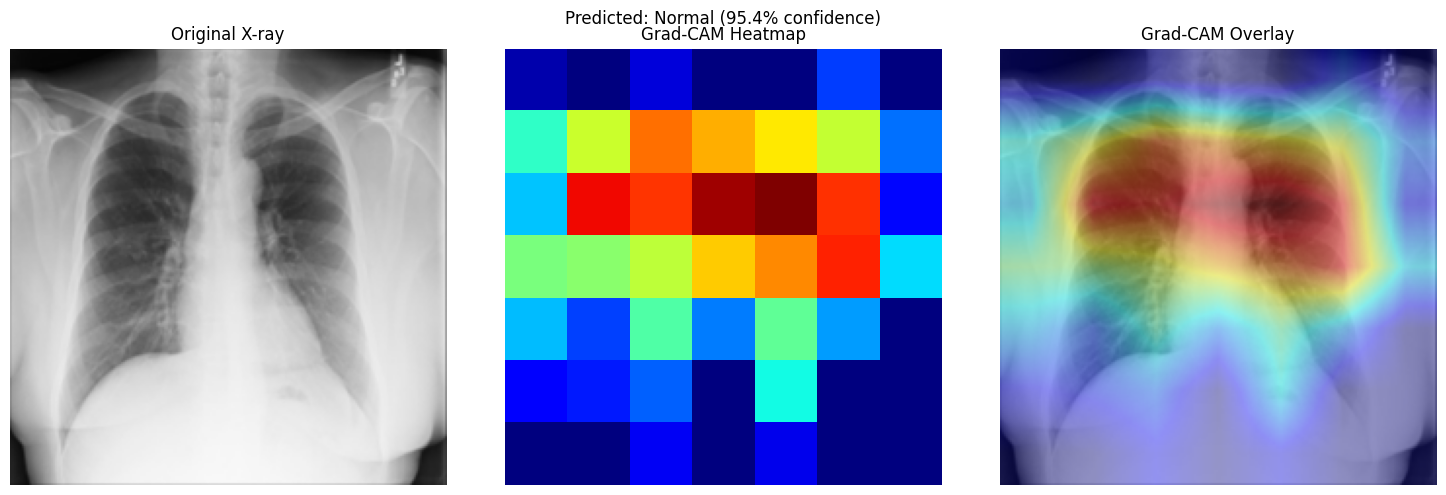

In [ ]:
sample_path = test_df.iloc[0]["image_path"]

result = generate_gradcam_for_image(
    sample_path
)

display_gradcam_result(result)

In [ ]:
def describe_activation_region(heatmap, threshold=0.6):
    """
    Locates the centroid of high-activation pixels in the Grad-CAM heatmap
    and translates it into a plain, purely spatial description.
    """

    ys, xs = np.where(heatmap >= threshold)

    if len(ys) == 0:
        return "diffuse regions across the lung fields"

    h, w = heatmap.shape

    cy, cx = ys.mean() / h, xs.mean() / w

    vertical = (
        "upper" if cy < 0.33
        else ("lower" if cy > 0.66 else "central")
    )

    horizontal = (
        "left" if cx < 0.33
        else ("right" if cx > 0.66 else "central")
    )

    if vertical == "central" and horizontal == "central":
        return "central lung field"

    return f"{vertical}-{horizontal} lung field"

In [ ]:
def explain_prediction(image_path):

    result = generate_gradcam_for_image(image_path)

    region_description = describe_activation_region(
        result["heatmap"]
    )

    explanation_text = (
        f"The model predicted '{result['predicted_class']}' with "
        f"{result['confidence']*100:.1f}% confidence. The model's activation was "
        f"concentrated primarily in the {region_description} of the image. This reflects "
        f"which pixels most influenced the model's output and is NOT a clinical finding "
        f"or diagnosis -- it should be interpreted only as an explanation of model behavior, "
        f"and any medical decision should involve a qualified radiologist."
    )

    return {
        "prediction": result["predicted_class"],
        "confidence": result["confidence"],
        "probabilities": result["probabilities"],
        "gradcam": {
            "heatmap": result["heatmap"],
            "overlay": result["overlay"]
        },
        "explanation": explanation_text,
    }

In [ ]:
out = explain_prediction(
    test_df.iloc[0]["image_path"]
)

print(out["explanation"])

The model predicted 'Normal' with 95.4% confidence. The model's activation was concentrated primarily in the upper-central lung field of the image. This reflects which pixels most influenced the model's output and is NOT a clinical finding or diagnosis -- it should be interpreted only as an explanation of model behavior, and any medical decision should involve a qualified radiologist.


In [ ]:
def predict_classification(image_path, model=None):
    if model is None:
        model = classifier

    # Load image
    raw_img = load_raw_image_for_display(image_path)

    # DenseNet preprocessing
    preprocessed = densenet_preprocess(
        tf.cast(raw_img, tf.float32)
    )

    # Add batch dimension
    img_array = tf.expand_dims(
        preprocessed,
        axis=0
    )

    # Prediction
    probs = model.predict(
        img_array,
        verbose=0
    )[0]

    # Predicted class
    pred_index = int(
        np.argmax(probs)
    )

    return {
        "predicted_class": CLASS_NAMES[pred_index],
        "confidence": float(probs[pred_index]),
        "class_probabilities": {
            CLASS_NAMES[i]: float(probs[i])
            for i in range(len(CLASS_NAMES))
        },
    }

In [ ]:
result = predict_classification(
    test_df.iloc[0]["image_path"]
)

print("Predicted class:", result["predicted_class"])
print("Confidence:", f"{result['confidence'] * 100:.2f}%")

print("\nClass probabilities:")
for class_name, probability in result["class_probabilities"].items():
    print(
        f"{class_name}: {probability * 100:.2f}%"
    )

Predicted class: Normal
Confidence: 95.36%

Class probabilities:
COVID: 1.37%
Lung_Opacity: 3.27%
Normal: 95.36%
Viral Pneumonia: 0.00%


In [15]:
def load_image_mask_pair(image_path, mask_path, training=False):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0   # simple [0,1] scaling; U-Net trained from scratch

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [MASK_SIZE, MASK_SIZE], method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.cast(mask > 0.5, tf.float32)

    if training:
        # Apply the SAME random transform to image and mask by sharing a
        # stateless-op seed, preserving spatial correspondence between them.
        seed = tf.random.uniform([2], maxval=100000, dtype=tf.int32)
        img = tf.image.stateless_random_flip_left_right(img, seed)
        mask = tf.image.stateless_random_flip_left_right(mask, seed)
        # (No up/down flip: chest X-rays have a fixed vertical orientation.)

        img = tf.image.stateless_random_brightness(img, max_delta=0.1, seed=seed)
        img = tf.image.stateless_random_contrast(img, lower=0.9, upper=1.1, seed=seed)
        img = tf.clip_by_value(img, 0.0, 1.0)

    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([MASK_SIZE, MASK_SIZE, 1])
    return img, mask

def make_segmentation_dataset(df, training=False, batch_size=BATCH_SIZE):
    df_valid = df.dropna(subset=["mask_path"])
    paths = df_valid["image_path"].values
    mask_paths = df_valid["mask_path"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, mask_paths))
    if training:
        ds = ds.shuffle(buffer_size=len(df_valid), seed=SEED)

    ds = ds.map(lambda p, m: load_image_mask_pair(p, m, training=training), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

seg_train_ds = make_segmentation_dataset(train_df, training=True)
seg_val_ds = make_segmentation_dataset(val_df, training=False)
seg_test_ds = make_segmentation_dataset(test_df, training=False)

In [22]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)

    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);    p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 512)   # bottleneck

    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(bn)
    u4 = layers.Concatenate()([u4, c4]); d4 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(d4)
    u3 = layers.Concatenate()([u3, c3]); d3 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(d3)
    u2 = layers.Concatenate()([u2, c2]); d2 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(d2)
    u1 = layers.Concatenate()([u1, c1]); d1 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)   # sigmoid: independent per-pixel lung/not-lung probability

    return keras.Model(inputs, outputs, name="lung_unet_segmenter")

segmenter = build_unet()
segmenter.summary()

Model: "lung_unet_segmenter"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 224, 224,  │      9,248 │ activation_10[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 112, 112,  │     36,928 │ activation_12[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_15[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [19]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    # BCE handles per-pixel classification; Dice directly optimizes overlap
    # and is more robust to the class imbalance between lung and background
    # pixels than BCE alone.
    bce = tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6, threshold=0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

segmenter.compile(
    optimizer=optimizers.Adam(learning_rate=SEG_LR),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric, "binary_accuracy"],
)

In [20]:
seg_callbacks = [
    callbacks.ModelCheckpoint(os.path.join(ARTIFACTS_DIR, "segmenter_best.keras"),
                               monitor="val_dice_coefficient", mode="max", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_dice_coefficient", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7),
]

In [21]:
seg_history = segmenter.fit(
    seg_train_ds, validation_data=seg_val_ds, epochs=SEG_EPOCHS, callbacks=seg_callbacks,
)

Epoch 1/40
463/463 ━━━━━━━━━━━━━━━━━━━━ 284s 451ms/step - binary_accuracy: 0.9112 - dice_coefficient: 0.6241 - iou_metric: 0.8273 - loss: 0.7516 - val_binary_accuracy: 0.9854 - val_dice_coefficient: 0.6879 - val_iou_metric: 0.9411 - val_loss: 0.5606 - learning_rate: 1.0000e-04
Epoch 2/40
463/463 ━━━━━━━━━━━━━━━━━━━━ 104s 224ms/step - binary_accuracy: 0.9855 - dice_coefficient: 0.7141 - iou_metric: 0.9419 - loss: 0.5076 - val_binary_accuracy: 0.9874 - val_dice_coefficient: 0.7402 - val_iou_metric: 0.9487 - val_loss: 0.4487 - learning_rate: 1.0000e-04
Epoch 3/40
463/463 ━━━━━━━━━━━━━━━━━━━━ 100s 217ms/step - binary_accuracy: 0.9880 - dice_coefficient: 0.7642 - iou_metric: 0.9516 - loss: 0.4029 - val_binary_accuracy: 0.9888 - val_dice_coefficient: 0.7861 - val_iou_metric: 0.9543 - val_loss: 0.3582 - learning_rate: 1.0000e-04
Epoch 4/40
463/463 ━━━━━━━━━━━━━━━━━━━━ 151s 237ms/step - binary_accuracy: 0.9893 - dice_coefficient: 0.8092 - iou_metric: 0.9566 - loss: 0.3173 - val_binary_accuracy

KeyboardInterrupt: 

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

source = "/content/artifacts"
destination = "/content/drive/MyDrive/artifacts"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Folder saved to Google Drive!")

Folder saved to Google Drive!


In [ ]:
seg_eval = segmenter.evaluate(seg_test_ds, return_dict=True)
print("Segmentation test-set metrics:", seg_eval)

def collect_segmentation_metrics(model, dataset):
    dices, ious = [], []
    for images, masks in dataset:
        preds = model.predict(images, verbose=0)
        for i in range(images.shape[0]):
            dices.append(float(dice_coefficient(masks[i], preds[i]).numpy()))
            ious.append(float(iou_metric(masks[i], preds[i]).numpy()))
    return np.array(dices), np.array(ious)

test_dices, test_ious = collect_segmentation_metrics(segmenter, seg_test_ds)
print(f"Mean Dice: {test_dices.mean():.4f} +/- {test_dices.std():.4f}")
print(f"Mean IoU:  {test_ious.mean():.4f} +/- {test_ious.std():.4f}")

segmentation_eval_results = {
    "mean_dice": float(test_dices.mean()), "mean_iou": float(test_ious.mean()),
    "std_dice": float(test_dices.std()), "std_iou": float(test_ious.std()),
    "keras_evaluate": {k: float(v) for k, v in seg_eval.items()},
}
with open(os.path.join(ARTIFACTS_DIR, "segmentation_evaluation.json"), "w") as f:
    json.dump(segmentation_eval_results, f, indent=2)

100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - binary_accuracy: 0.9933 - dice_coefficient: 0.9838 - iou_metric: 0.9724 - loss: 0.0352
Segmentation test-set metrics: {'binary_accuracy': 0.9932867288589478, 'dice_coefficient': 0.9838117361068726, 'iou_metric': 0.9724265933036804, 'loss': 0.03521329537034035}
Mean Dice: 0.9825 +/- 0.0164
Mean IoU:  0.9705 +/- 0.0278


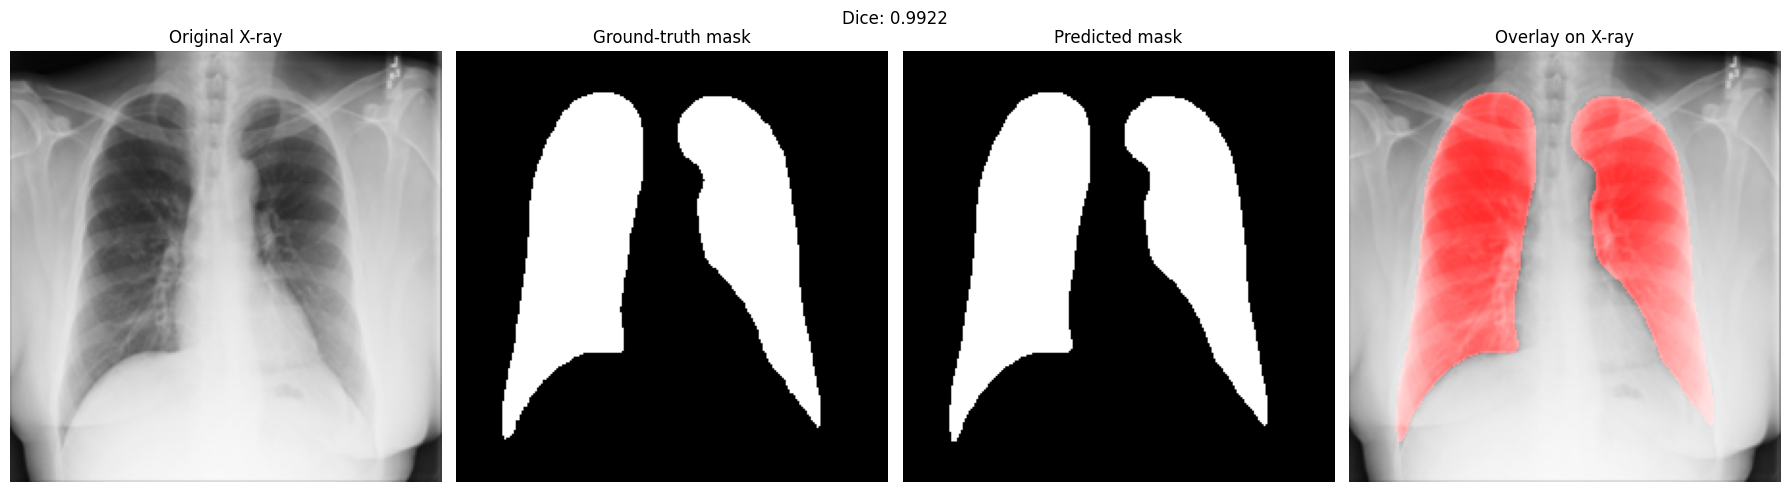

0.9921990633010864

In [ ]:
def visualize_segmentation(image_path, mask_path, model=segmenter):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_norm = tf.cast(img, tf.float32) / 255.0

    gt_mask = tf.io.read_file(mask_path)
    gt_mask = tf.io.decode_image(gt_mask, channels=1, expand_animations=False)
    gt_mask = tf.image.resize(gt_mask, [MASK_SIZE, MASK_SIZE], method="nearest")
    gt_mask = tf.cast(gt_mask, tf.float32) / 255.0
    gt_mask = tf.cast(gt_mask > 0.5, tf.float32)

    pred_mask = model.predict(tf.expand_dims(img_norm, 0), verbose=0)[0]
    pred_mask_bin = (pred_mask > 0.5).astype(np.float32)
    dice = dice_coefficient(gt_mask, pred_mask).numpy()

    img_uint8 = tf.cast(img, tf.uint8).numpy()
    overlay = img_uint8.copy()
    overlay[..., 0] = np.where(pred_mask_bin.squeeze() > 0.5, 255, overlay[..., 0])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(img_uint8); axes[0].set_title("Original X-ray"); axes[0].axis("off")
    axes[1].imshow(gt_mask.numpy().squeeze(), cmap="gray"); axes[1].set_title("Ground-truth mask"); axes[1].axis("off")
    axes[2].imshow(pred_mask_bin.squeeze(), cmap="gray"); axes[2].set_title("Predicted mask"); axes[2].axis("off")
    axes[3].imshow(overlay); axes[3].set_title("Overlay on X-ray"); axes[3].axis("off")
    fig.suptitle(f"Dice: {dice:.4f}")
    plt.tight_layout()
    plt.show()
    return float(dice)

def predict_segmentation(image_path, mask_path=None, model=None):
    if model is None:
        model = segmenter
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_norm = tf.cast(img, tf.float32) / 255.0
    pred_mask = model.predict(tf.expand_dims(img_norm, 0), verbose=0)[0]

    result = {"mask": pred_mask}
    if mask_path is not None and isinstance(mask_path, str) and os.path.exists(mask_path):
        gt_mask = tf.io.read_file(mask_path)
        gt_mask = tf.io.decode_image(gt_mask, channels=1, expand_animations=False)
        gt_mask = tf.image.resize(gt_mask, [MASK_SIZE, MASK_SIZE], method="nearest")
        gt_mask = tf.cast(gt_mask, tf.float32) / 255.0
        gt_mask = tf.cast(gt_mask > 0.5, tf.float32)
        result["dice"] = float(dice_coefficient(gt_mask, pred_mask).numpy())
    return result

# Example:
row = test_df.dropna(subset=["mask_path"]).iloc[0]
visualize_segmentation(row["image_path"], row["mask_path"])

In [ ]:
def analyze_xray(image_path, mask_path=None):
    classification_result = predict_classification(image_path)
    gradcam_result = generate_gradcam_for_image(image_path)
    segmentation_result = predict_segmentation(image_path, mask_path=mask_path)

    return {
        "image_path": image_path,
        "classification": classification_result,
        "gradcam": {"heatmap": gradcam_result["heatmap"], "overlay": gradcam_result["overlay"]},
        "segmentation": segmentation_result,
    }

# Example:
row = test_df.dropna(subset=["mask_path"]).iloc[0]
result = analyze_xray(row["image_path"], mask_path=row["mask_path"])
print(result["classification"])

{'predicted_class': 'Normal', 'confidence': 0.95358806848526, 'class_probabilities': {'COVID': 0.01367667131125927, 'Lung_Opacity': 0.032735344022512436, 'Normal': 0.95358806848526, 'Viral Pneumonia': 7.343832209016909e-10}}


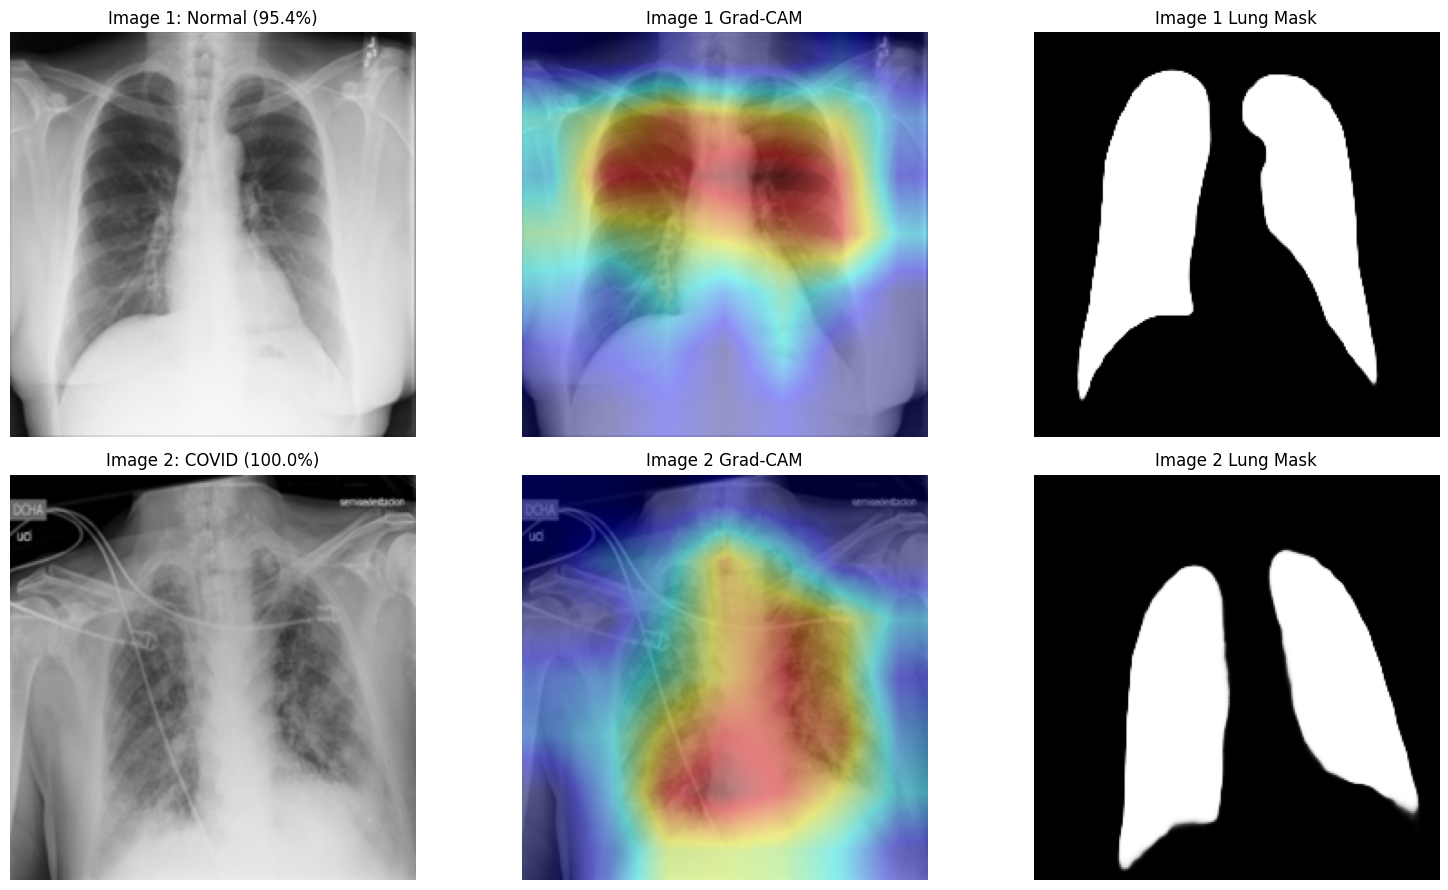

=== Measurable Model-Output Differences ===
Predicted class changed: True  (Normal -> COVID)
Confidence change: +4.6 percentage points
Lung-mask area change: -0.28% of image area
Grad-CAM attention region overlap (IoU): 0.368

Per-class probability change:
  COVID: +98.6 pts
  Lung_Opacity: -3.3 pts
  Normal: -95.4 pts
  Viral Pneumonia: -0.0 pts

These are quantitative differences in MODEL OUTPUTS between the two images, not a medical assessment of disease progression. A change in predicted class, confidence, probabilities, segmented lung-opacity area, or Grad-CAM attention region does not by itself indicate clinical improvement or worsening. This system does not determine whether a change is 'good' or 'bad' -- that interpretation requires a qualified radiologist reviewing both images directly, ideally alongside clinical history and other diagnostic information.


In [ ]:
def _gradcam_region_overlap(heatmap1, heatmap2, threshold=0.6):
    """
    IoU between the high-activation regions (>= threshold) of two Grad-CAM
    heatmaps. Lower = the model attended to different regions across the
    two images; higher = similar regions. Purely a geometric similarity
    measure, not a clinical signal.
    """
    h1 = (heatmap1 >= threshold)
    h2 = (heatmap2 >= threshold)
    union = np.logical_or(h1, h2).sum()
    if union == 0:
        return None
    return float(np.logical_and(h1, h2).sum() / union)

def analyze_two_xrays(image1_path, image2_path, mask1_path=None, mask2_path=None):
    """
    Runs both independent models on two X-rays and reports MEASURABLE
    differences in model outputs only. Does NOT diagnose disease
    progression and does NOT label any change as "good" or "bad".
    """
    result1 = analyze_xray(image1_path, mask_path=mask1_path)
    result2 = analyze_xray(image2_path, mask_path=mask2_path)

    class1 = result1["classification"]["predicted_class"]
    class2 = result2["classification"]["predicted_class"]
    conf1 = result1["classification"]["confidence"]
    conf2 = result2["classification"]["confidence"]
    probs1 = result1["classification"]["class_probabilities"]
    probs2 = result2["classification"]["class_probabilities"]

    probability_deltas = {cls: float(probs2[cls] - probs1[cls]) for cls in CLASS_NAMES}

    total_pixels = IMG_SIZE * IMG_SIZE
    mask1_pct = 100 * float(np.sum(result1["segmentation"]["mask"] > 0.5)) / total_pixels
    mask2_pct = 100 * float(np.sum(result2["segmentation"]["mask"] > 0.5)) / total_pixels

    gradcam_overlap = _gradcam_region_overlap(result1["gradcam"]["heatmap"], result2["gradcam"]["heatmap"])

    comparison = {
        "image_1": {"predicted_class": class1, "confidence": conf1, "probabilities": probs1,
                     "lung_mask_area_pct": mask1_pct},
        "image_2": {"predicted_class": class2, "confidence": conf2, "probabilities": probs2,
                     "lung_mask_area_pct": mask2_pct},
        "measurable_differences": {
            "predicted_class_changed": class1 != class2,
            "confidence_delta": float(conf2 - conf1),                       # + = image 2 more confident
            "class_probability_deltas": probability_deltas,                  # + = probability rose in image 2
            "lung_mask_area_pct_change": float(mask2_pct - mask1_pct),       # + = larger flagged area in image 2
            "gradcam_region_overlap_iou": gradcam_overlap,                   # 0-1, geometric similarity only
        },
        "disclaimer": (
            "These are quantitative differences in MODEL OUTPUTS between the two images, "
            "not a medical assessment of disease progression. A change in predicted class, "
            "confidence, probabilities, segmented lung-opacity area, or Grad-CAM attention "
            "region does not by itself indicate clinical improvement or worsening. This "
            "system does not determine whether a change is 'good' or 'bad' -- that "
            "interpretation requires a qualified radiologist reviewing both images directly, "
            "ideally alongside clinical history and other diagnostic information."
        ),
    }
    return comparison, result1, result2

def display_two_xray_comparison(comparison, result1, result2):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    img1 = load_raw_image_for_display(result1["image_path"])
    img2 = load_raw_image_for_display(result2["image_path"])

    axes[0, 0].imshow(img1)
    axes[0, 0].set_title(f"Image 1: {comparison['image_1']['predicted_class']} "
                          f"({comparison['image_1']['confidence']*100:.1f}%)")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(result1["gradcam"]["overlay"]); axes[0, 1].set_title("Image 1 Grad-CAM"); axes[0, 1].axis("off")
    axes[0, 2].imshow(result1["segmentation"]["mask"].squeeze(), cmap="gray")
    axes[0, 2].set_title("Image 1 Lung Mask"); axes[0, 2].axis("off")

    axes[1, 0].imshow(img2)
    axes[1, 0].set_title(f"Image 2: {comparison['image_2']['predicted_class']} "
                          f"({comparison['image_2']['confidence']*100:.1f}%)")
    axes[1, 0].axis("off")
    axes[1, 1].imshow(result2["gradcam"]["overlay"]); axes[1, 1].set_title("Image 2 Grad-CAM"); axes[1, 1].axis("off")
    axes[1, 2].imshow(result2["segmentation"]["mask"].squeeze(), cmap="gray")
    axes[1, 2].set_title("Image 2 Lung Mask"); axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

    diffs = comparison["measurable_differences"]
    print("=== Measurable Model-Output Differences ===")
    print(f"Predicted class changed: {diffs['predicted_class_changed']}  "
          f"({comparison['image_1']['predicted_class']} -> {comparison['image_2']['predicted_class']})")
    print(f"Confidence change: {diffs['confidence_delta']*100:+.1f} percentage points")
    print(f"Lung-mask area change: {diffs['lung_mask_area_pct_change']:+.2f}% of image area")
    if diffs["gradcam_region_overlap_iou"] is not None:
        print(f"Grad-CAM attention region overlap (IoU): {diffs['gradcam_region_overlap_iou']:.3f}")
    print("\nPer-class probability change:")
    for cls, d in diffs["class_probability_deltas"].items():
        print(f"  {cls}: {d*100:+.1f} pts")
    print(f"\n{comparison['disclaimer']}")

# Example:
rows = test_df.dropna(subset=["mask_path"])
r1, r2 = rows.iloc[0], rows.iloc[1]
comparison, res1, res2 = analyze_two_xrays(r1["image_path"], r2["image_path"], r1["mask_path"], r2["mask_path"])
display_two_xray_comparison(comparison, res1, res2)

In [ ]:
classifier.save(CLASSIFICATION_MODEL_PATH)
segmenter.save(SEGMENTATION_MODEL_PATH)

with open(os.path.join(ARTIFACTS_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)

preprocessing_config = {
    "img_size": IMG_SIZE,
    "classifier_preprocessing": "DenseNet121 (tf.keras.applications.densenet.preprocess_input)",
    "segmenter_preprocessing": "divide by 255.0 to [0,1] range",
    "mask_binarization_threshold": 0.5,
}
with open(os.path.join(ARTIFACTS_DIR, "preprocessing_config.json"), "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"Saved classifier to: {CLASSIFICATION_MODEL_PATH}")
print(f"Saved segmenter to:  {SEGMENTATION_MODEL_PATH}")
print(f"Artifacts (history, evaluation, configs) saved in: {ARTIFACTS_DIR}/")

Saved classifier to: chest_xray_classifier.keras
Saved segmenter to:  lung_segmentation.keras
Artifacts (history, evaluation, configs) saved in: artifacts/


In [ ]:
import shutil

source = "/content/artifacts"
destination = "/content/drive/MyDrive/artifacts"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Folder saved to Google Drive!")

Folder saved to Google Drive!
